# Buy–sell symmetry of the impact response

The main response analysis folds positive and negative imbalance together by
multiplying returns by the imbalance sign. This notebook checks the implied
odd-symmetry assumption without expanding the full regime analysis.

We compare buy- and sell-dominated bars at the same absolute normalized
imbalance for three samples:

1. pooled 4,000-event bars;
2. the highest-speed quintile of 4,000-event bars; and
3. the highest-event-count quintile of five-minute bars.

Common absolute-imbalance bins are appropriate here because symmetry is a
comparison at the same imbalance magnitude. The principal outputs are a
three-panel figure and compact diagnostic tables. Day-block bootstrap results
and a day-demeaned-return sensitivity are included as robustness checks.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

NOTEBOOK_DIR = Path.cwd()
default_project = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
PROJECT_DIR = Path(os.environ.get('CRYPTO_IMPACT_PROJECT_DIR', default_project)).resolve()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.crypto_impact.impact import add_trailing_impact_normalisation
from src.crypto_impact.monthly_eda import (
    build_fixed_event_bars,
    load_monthly_trades,
    make_time_bars,
)
from src.crypto_impact.regime_analysis import add_market_regimes, build_analysis_table
from src.crypto_impact.regression import compare_impact_models

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')


In [2]:
# Corrected trade events (one event per same-sign run of fills at a millisecond
# timestamp, priced at the run's last fill; scripts/export_paper_events.py), on the
# shared data drive. The legacy files in data/raw/BTCUSDT_monthly (first-fill price
# and sign per timestamp, 2025-01..2026-05) are no longer used.
SHARED_ACADEMIC = PROJECT_DIR.parent / 'shared-data' / 'features' / 'academic' / 'symbol=BTCUSDT'
DATA_DIR = Path(os.environ.get('CRYPTO_IMPACT_DATA_DIR', SHARED_ACADEMIC / 'paper_events_v2'))
SAMPLE_START = os.environ.get('CRYPTO_IMPACT_SAMPLE_START', '2021-01')
SAMPLE_END = os.environ.get('CRYPTO_IMPACT_SAMPLE_END', '2026-08')
assert SAMPLE_END <= '2026-08', 'Data from 2026-09 onward is reserved for the alpha-search P-006 test.'
# Redo outputs sit beside the other full-sample notebook reruns, so the paper's
# original reports/figures and reports/tables are not overwritten.
FIGURE_DIR = Path(
    os.environ.get('CRYPTO_IMPACT_FIGURE_DIR', PROJECT_DIR / 'reports' / 'redo' / 'paper' / 'figures')
)
TABLE_DIR = Path(
    os.environ.get('CRYPTO_IMPACT_TABLE_DIR', PROJECT_DIR / 'reports' / 'redo' / 'paper' / 'tables')
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

EVENTS_PER_BAR = 4_000
TIME_WINDOW = '5min'
TRAILING_WINDOW = '1D'
MIN_TRAILING_BARS = 100
N_BINS = 20
MIN_OBS_PER_SIDE_BIN = 20
N_BOOTSTRAP = int(os.environ.get('CRYPTO_IMPACT_N_BOOTSTRAP', '200'))
MAX_FILES_ENV = int(os.environ.get('CRYPTO_IMPACT_MAX_FILES', '0'))
MAX_FILES = MAX_FILES_ENV or None

files = sorted(
    path for path in DATA_DIR.glob('BTCUSDT-trades-*.parquet')
    if SAMPLE_START <= path.stem.removeprefix('BTCUSDT-trades-') <= SAMPLE_END
)
if MAX_FILES is not None:
    files = files[:MAX_FILES]
if not files:
    raise FileNotFoundError(f'No monthly parquet files found in {DATA_DIR}')
print(f'Files selected: {len(files)} ({files[0].name} to {files[-1].name})')


Files selected: 68 (BTCUSDT-trades-2021-01.parquet to BTCUSDT-trades-2026-08.parquet)


## Data preparation

`normalised_signed_impact` is already oriented in the direction of imbalance:
it equals the contemporaneous return multiplied by the imbalance sign and
divided by trailing realized volatility. Hence symmetry implies equality of
its conditional mean between buy- and sell-dominated bars at the same
`normalised_imbalance`.


In [3]:
DURATION_ORDER = [
    'very_short_duration', 'short_duration', 'medium_duration',
    'long_duration', 'very_long_duration',
]
TIME_ACTIVITY_ORDER = [
    'very_low_activity', 'low_activity', 'medium_activity',
    'high_activity', 'very_high_activity',
]


def prepare_normalised_analysis(bars):
    analysis = build_analysis_table(bars, horizons=())
    analysis = add_trailing_impact_normalisation(
        analysis,
        window=TRAILING_WINDOW,
        min_periods=MIN_TRAILING_BARS,
        timestamp_col='end_time',
    ).replace([np.inf, -np.inf], np.nan)
    analysis['block_day'] = pd.to_datetime(
        analysis['end_time'], utc=True
    ).dt.floor('D')
    imbalance_sign = np.sign(analysis['signed_imbalance'])
    # Zero-imbalance bars get no side (NaN) and drop out of the Buy/Sell comparison.
    analysis['imbalance_side'] = imbalance_sign.map({1.0: 'Buy', -1.0: 'Sell'})
    raw_normalised_return = (
        analysis['current_return_bps']
        / analysis['trailing_realised_volatility_bps']
    )
    day_mean_return = raw_normalised_return.groupby(analysis['block_day']).transform('mean')
    analysis['normalised_directional_impact_demeaned'] = (
        imbalance_sign * (raw_normalised_return - day_mean_return)
    )
    return analysis


def add_quantile_regime(data, source_col, regime_col, labels):
    result = data.copy()
    result[regime_col] = pd.qcut(result[source_col], q=len(labels), labels=labels)
    return result


In [4]:
event_bars = build_fixed_event_bars(files, events_per_bar=EVENTS_PER_BAR)
event_analysis = add_market_regimes(prepare_normalised_analysis(event_bars))

time_frames = []
for path in files:
    monthly = make_time_bars(load_monthly_trades(path), window=TIME_WINDOW)
    monthly['start_time'] = monthly.index
    monthly['end_time'] = monthly.index + pd.Timedelta(TIME_WINDOW)
    monthly['duration_seconds'] = pd.Timedelta(TIME_WINDOW).total_seconds()
    time_frames.append(monthly)
time_bars = pd.concat(time_frames).sort_index()
if not time_bars.index.is_unique:
    raise ValueError('Five-minute bar start times are not unique.')
time_analysis = add_quantile_regime(
    prepare_normalised_analysis(time_bars),
    'trade_count', 'time_activity_regime', TIME_ACTIVITY_ORDER,
)

analysis_samples = {
    'Pooled event bars': event_analysis,
    'Highest-speed event bars': event_analysis.loc[
        event_analysis['duration_regime'] == 'very_short_duration'
    ],
    'Highest-activity time bars': time_analysis.loc[
        time_analysis['time_activity_regime'] == 'very_high_activity'
    ],
}

pd.DataFrame({
    name: {
        'observations': len(sample),
        'days': sample['block_day'].nunique(),
        'buy_share': (sample['imbalance_side'] == 'Buy').mean(),
    }
    for name, sample in analysis_samples.items()
}).T


,observations,days,buy_share
Pooled event bars,"584,092.000000","2,069.000000",0.492282
Highest-speed event bars,"116,819.000000","1,937.000000",0.498720
Highest-activity time bars,"119,107.000000","2,019.000000",0.497687


## Matched-bin symmetry diagnostics

For each sample, the support is restricted to the overlap of the observed
buy and sell absolute-imbalance ranges. Equal-count edges are then constructed
from the pooled observations on that overlap and applied to both sides.


In [5]:
def matched_side_curve(data, impact_col='normalised_signed_impact', n_bins=N_BINS):
    columns = [
        'normalised_imbalance', impact_col, 'imbalance_side', 'block_day'
    ]
    sample = (
        data.loc[:, columns]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )
    sample = sample.loc[
        (sample['normalised_imbalance'] > 0)
        & sample['imbalance_side'].isin(['Buy', 'Sell'])
    ].copy()
    support = sample.groupby('imbalance_side', observed=True)[
        'normalised_imbalance'
    ].agg(['min', 'max'])
    lower = float(support['min'].max())
    upper = float(support['max'].min())
    sample = sample.loc[sample['normalised_imbalance'].between(lower, upper)].copy()

    edges = np.unique(
        sample['normalised_imbalance']
        .quantile(np.linspace(0.0, 1.0, n_bins + 1))
        .to_numpy()
    )
    if len(edges) != n_bins + 1:
        raise ValueError('Insufficient distinct imbalance values for matched bins.')
    edges[0] = np.nextafter(edges[0], -np.inf)
    edges[-1] = np.nextafter(edges[-1], np.inf)
    sample['bin_id'] = pd.cut(
        sample['normalised_imbalance'], edges,
        labels=False, include_lowest=True,
    )
    curve = (
        sample.groupby(['imbalance_side', 'bin_id'], observed=True)
        .agg(
            mean_x=('normalised_imbalance', 'mean'),
            median_x=('normalised_imbalance', 'median'),
            mean_impact=(impact_col, 'mean'),
            median_impact=(impact_col, 'median'),
            impact_std=(impact_col, 'std'),
            n_obs=(impact_col, 'count'),
        )
        .reset_index()
    )
    curve['standard_error'] = curve['impact_std'] / np.sqrt(curve['n_obs'])
    counts = curve.groupby('bin_id', observed=True)['imbalance_side'].nunique()
    common_bins = counts.index[counts == 2]
    curve = curve.loc[
        curve['bin_id'].isin(common_bins)
        & (curve['n_obs'] >= MIN_OBS_PER_SIDE_BIN)
    ].copy()
    counts = curve.groupby('bin_id', observed=True)['imbalance_side'].nunique()
    curve = curve.loc[curve['bin_id'].isin(counts.index[counts == 2])]
    curve['bin_id'] = curve['bin_id'].astype(int)
    return sample, curve.sort_values(['imbalance_side', 'bin_id']), edges


def log_fit(curve, x_scale):
    comparison, predictions = compare_impact_models(
        curve,
        min_obs_per_bin=MIN_OBS_PER_SIDE_BIN,
        x_scale=x_scale,
    )
    row = comparison.set_index('model').loc['logarithmic']
    prediction = predictions.loc[
        predictions['model'] == 'logarithmic', 'predicted_impact'
    ].to_numpy()
    fitted = curve.copy()
    fitted['log_prediction'] = prediction
    return row, fitted


def calculate_symmetry_diagnostics(data, impact_col='normalised_signed_impact'):
    matched, curve, edges = matched_side_curve(data, impact_col=impact_col)
    x_scale = float(matched['normalised_imbalance'].median())
    symmetric_fit, symmetric_curve = log_fit(curve, x_scale)

    side_frames = []
    side_parameter_rows = []
    separate_weighted_ss = 0.0
    separate_weight_sum = 0.0
    for side in ['Sell', 'Buy']:
        side_curve = curve.loc[curve['imbalance_side'] == side].copy()
        fit, fitted = log_fit(side_curve, x_scale)
        sigma = fitted['standard_error'].to_numpy()
        weights = 1.0 / sigma**2
        residual = fitted['mean_impact'].to_numpy() - fitted['log_prediction'].to_numpy()
        separate_weighted_ss += float(np.sum(weights * residual**2))
        separate_weight_sum += float(np.sum(weights))
        fitted['fit_type'] = 'side_specific'
        side_frames.append(fitted)
        side_parameter_rows.append({
            'side': side,
            'log_amplitude': fit['amplitude'],
            'log_curvature': fit['curvature'],
            'log_x0': x_scale / fit['curvature'],
            'weighted_rmse': fit['weighted_rmse'],
            'bins_used': int(fit['bins_used']),
        })
    side_fitted = pd.concat(side_frames, ignore_index=True)
    separate_wrmse = np.sqrt(separate_weighted_ss / separate_weight_sum)

    mean_pivot = curve.pivot(index='bin_id', columns='imbalance_side', values='mean_impact')
    se_pivot = curve.pivot(index='bin_id', columns='imbalance_side', values='standard_error')
    n_pivot = curve.pivot(index='bin_id', columns='imbalance_side', values='n_obs')
    gap = pd.DataFrame(index=mean_pivot.index)
    gap['buy_minus_sell'] = mean_pivot['Buy'] - mean_pivot['Sell']
    gap['gap_standard_error'] = np.sqrt(se_pivot['Buy']**2 + se_pivot['Sell']**2)
    gap['gap_z'] = gap['buy_minus_sell'] / gap['gap_standard_error']
    gap['n_buy'] = n_pivot['Buy']
    gap['n_sell'] = n_pivot['Sell']
    gap['buy_share'] = gap['n_buy'] / (gap['n_buy'] + gap['n_sell'])
    gap_weights = 1.0 / gap['gap_standard_error']**2
    weighted_gap = float(np.sum(gap_weights * gap['buy_minus_sell']) / np.sum(gap_weights))
    weighted_gap_se = float(np.sqrt(1.0 / np.sum(gap_weights)))
    tail = gap.iloc[-1]

    summary = {
        'observations_common_support': len(matched),
        'days': matched['block_day'].nunique(),
        'buy_share': (matched['imbalance_side'] == 'Buy').mean(),
        'bins_per_side': curve['bin_id'].nunique(),
        'common_support_min_x': matched['normalised_imbalance'].min(),
        'common_support_max_x': matched['normalised_imbalance'].max(),
        'weighted_mean_buy_minus_sell': weighted_gap,
        'weighted_mean_gap_se': weighted_gap_se,
        'weighted_mean_gap_z': weighted_gap / weighted_gap_se,
        'rms_bin_gap': float(np.sqrt(np.mean(gap['buy_minus_sell']**2))),
        'max_abs_bin_gap_z': float(gap['gap_z'].abs().max()),
        'final_bin_buy_minus_sell': float(tail['buy_minus_sell']),
        'final_bin_gap_se': float(tail['gap_standard_error']),
        'final_bin_gap_z': float(tail['gap_z']),
        'final_bin_buy_share': float(tail['buy_share']),
        'symmetric_log_wrmse': float(symmetric_fit['weighted_rmse']),
        'side_specific_log_wrmse': float(separate_wrmse),
        'side_specific_wrmse_improvement_pct': float(
            100 * (symmetric_fit['weighted_rmse'] - separate_wrmse)
            / symmetric_fit['weighted_rmse']
        ),
    }
    return {
        'summary': summary,
        'curve': curve,
        'side_fitted': side_fitted,
        'symmetric_fit': symmetric_fit,
        'symmetric_curve': symmetric_curve,
        'side_parameters': pd.DataFrame(side_parameter_rows),
        'gap': gap.reset_index(),
        'matched': matched,
        'edges': edges,
        'x_scale': x_scale,
    }


In [6]:
results = {
    name: calculate_symmetry_diagnostics(sample)
    for name, sample in analysis_samples.items()
}
symmetry_diagnostics = pd.DataFrame({
    name: result['summary'] for name, result in results.items()
}).T
symmetry_diagnostics.index.name = 'sample'

display_columns = [
    'observations_common_support', 'buy_share', 'bins_per_side',
    'weighted_mean_buy_minus_sell', 'weighted_mean_gap_z',
    'final_bin_buy_minus_sell', 'final_bin_gap_z', 'final_bin_buy_share',
    'side_specific_wrmse_improvement_pct',
]
symmetry_diagnostics[display_columns]


,observations_common_support,buy_share,bins_per_side,weighted_mean_buy_minus_sell,weighted_mean_gap_z,final_bin_buy_minus_sell,final_bin_gap_z,final_bin_buy_share,side_specific_wrmse_improvement_pct
sample,,,,,,,,,
Pooled event bars,"576,680.000000",0.492412,20.000000,0.001500,15.259510,0.001280,1.394313,0.485503,35.046680
Highest-speed event bars,"116,620.000000",0.498671,20.000000,0.001353,5.485780,-0.003457,-1.314704,0.476419,9.525218
Highest-activity time bars,"119,101.000000",0.497687,20.000000,0.001453,5.022660,-0.002115,-0.426945,0.484635,6.538096


## Directional response curves

Points are side-specific conditional means on identical bin edges. Solid
lines are independently fitted logarithmic curves. The dashed line is the
symmetric logarithmic fit imposed across both sides.


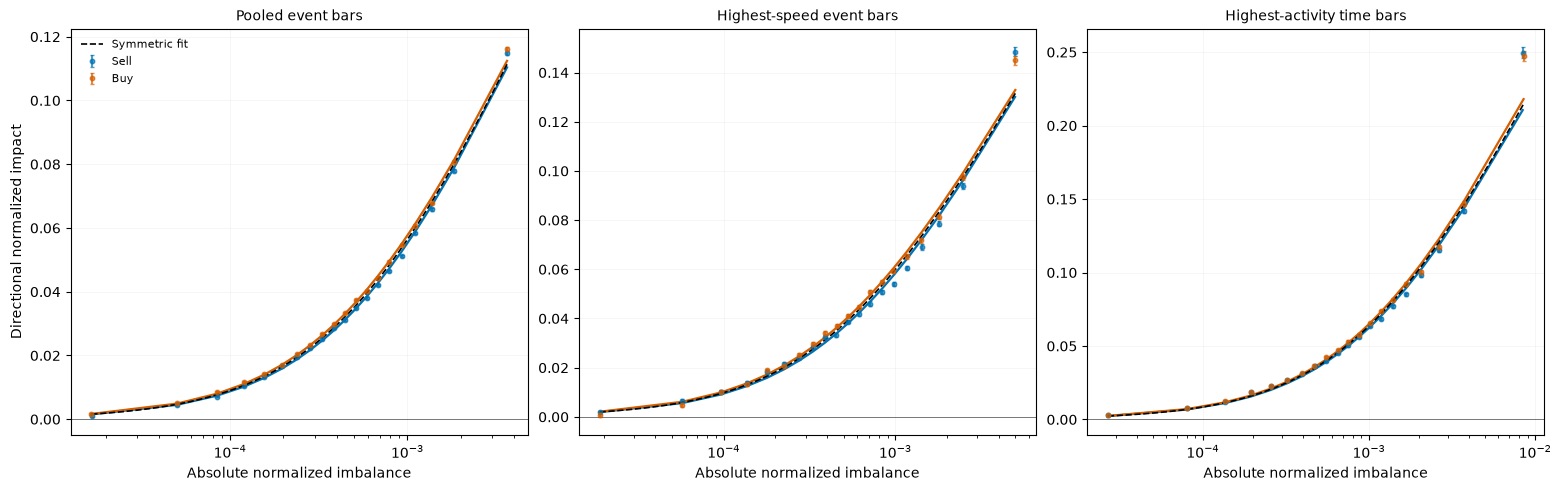

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8), constrained_layout=True)
colours = {'Buy': '#D55E00', 'Sell': '#0072B2'}

for ax, (name, result) in zip(axes, results.items()):
    curve = result['curve']
    for side in ['Sell', 'Buy']:
        observed = curve.loc[curve['imbalance_side'] == side].sort_values('mean_x')
        fitted = result['side_fitted'].loc[
            result['side_fitted']['imbalance_side'] == side
        ].sort_values('mean_x')
        ax.errorbar(
            observed['mean_x'], observed['mean_impact'],
            yerr=observed['standard_error'], fmt='o', ms=3.2,
            color=colours[side], alpha=0.70, capsize=1.5, label=side,
        )
        ax.plot(
            fitted['mean_x'], fitted['log_prediction'],
            color=colours[side], lw=1.6,
        )
    symmetric = result['symmetric_fit']
    x_grid = np.geomspace(curve['mean_x'].min(), curve['mean_x'].max(), 250)
    y_grid = symmetric['amplitude'] * np.log1p(
        symmetric['curvature'] * x_grid / result['x_scale']
    )
    ax.plot(x_grid, y_grid, color='black', ls='--', lw=1.2, label='Symmetric fit')
    ax.axhline(0, color='black', lw=0.6, alpha=0.6)
    ax.set_xscale('log')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Absolute normalized imbalance')
    ax.grid(alpha=0.15, linewidth=0.5)

axes[0].set_ylabel('Directional normalized impact')
axes[0].legend(loc='upper left', frameon=False, fontsize=8)
fig.savefig(FIGURE_DIR / '17_imbalance_response_symmetry.pdf', bbox_inches='tight')
plt.show()


## Day-block bootstrap

Complete UTC days are resampled. The scalar diagnostics are the
inverse-variance-weighted mean buy-minus-sell gap across matched bins and the
gap in the final matched bin. A confidence interval containing zero is
consistent with symmetry for that scalar diagnostic; the curve and fit
comparison remain important if bin-level differences change sign.


In [8]:
def bootstrap_side_gaps(data, n_bootstrap=N_BOOTSTRAP, random_state=0):
    columns = [
        'normalised_imbalance', 'normalised_signed_impact',
        'imbalance_side', 'block_day',
    ]
    sample = data.loc[:, columns].replace([np.inf, -np.inf], np.nan).dropna()
    sample = sample.reset_index(drop=True)
    day_indices = {
        day: group.index.to_numpy()
        for day, group in sample.groupby('block_day', observed=True)
    }
    days = np.asarray(list(day_indices), dtype=object)
    if len(days) < 2:
        raise ValueError('At least two UTC days are required for the bootstrap.')
    rng = np.random.default_rng(random_state)
    rows = []
    for bootstrap_sample in range(n_bootstrap):
        sampled_days = rng.choice(days, size=len(days), replace=True)
        indices = np.concatenate([day_indices[day] for day in sampled_days])
        draw = sample.iloc[indices]
        try:
            result = calculate_symmetry_diagnostics(draw)
        except (RuntimeError, ValueError):
            continue
        summary = result['summary']
        rows.append({
            'bootstrap_sample': bootstrap_sample,
            'weighted_mean_buy_minus_sell': summary['weighted_mean_buy_minus_sell'],
            'final_bin_buy_minus_sell': summary['final_bin_buy_minus_sell'],
        })
    return pd.DataFrame(rows)


bootstrap_frames = []
bootstrap_summary_rows = []
for sample_number, (name, sample) in enumerate(analysis_samples.items()):
    draws = bootstrap_side_gaps(
        sample,
        n_bootstrap=N_BOOTSTRAP,
        random_state=2_000 + sample_number,
    )
    draws.insert(0, 'sample', name)
    bootstrap_frames.append(draws)
    bootstrap_summary_rows.append({
        'sample': name,
        'bootstrap_samples': len(draws),
        'mean_gap_p025': draws['weighted_mean_buy_minus_sell'].quantile(0.025),
        'mean_gap_p975': draws['weighted_mean_buy_minus_sell'].quantile(0.975),
        'tail_gap_p025': draws['final_bin_buy_minus_sell'].quantile(0.025),
        'tail_gap_p975': draws['final_bin_buy_minus_sell'].quantile(0.975),
    })

symmetry_bootstrap = pd.concat(bootstrap_frames, ignore_index=True)
bootstrap_summary = pd.DataFrame(bootstrap_summary_rows).set_index('sample')
symmetry_diagnostics = symmetry_diagnostics.join(bootstrap_summary)
symmetry_diagnostics[[
    'weighted_mean_buy_minus_sell', 'mean_gap_p025', 'mean_gap_p975',
    'final_bin_buy_minus_sell', 'tail_gap_p025', 'tail_gap_p975',
    'side_specific_wrmse_improvement_pct',
]]


,weighted_mean_buy_minus_sell,mean_gap_p025,mean_gap_p975,final_bin_buy_minus_sell,tail_gap_p025,tail_gap_p975,side_specific_wrmse_improvement_pct
sample,,,,,,,
Pooled event bars,0.001500,0.001243,0.001769,0.001280,-0.000578,0.003314,35.046680
Highest-speed event bars,0.001353,0.000730,0.002103,-0.003457,-0.009725,0.002053,9.525218
Highest-activity time bars,0.001453,0.000667,0.002178,-0.002115,-0.011078,0.009132,6.538096


## Drift-adjusted sensitivity

A persistent positive or negative return within a day can produce apparent
buy–sell asymmetry after orienting returns by imbalance sign. As a sensitivity
check, the following calculation subtracts each UTC day's mean normalized raw
return before applying the imbalance sign. This is not the primary response
definition; it is used only to assess whether directional differences are
largely explained by day-level drift.


In [9]:
drift_adjusted_results = {
    name: calculate_symmetry_diagnostics(
        sample, impact_col='normalised_directional_impact_demeaned'
    )
    for name, sample in analysis_samples.items()
}
drift_adjusted_diagnostics = pd.DataFrame({
    name: result['summary'] for name, result in drift_adjusted_results.items()
}).T
drift_adjusted_diagnostics.index.name = 'sample'
drift_adjusted_diagnostics[[
    'weighted_mean_buy_minus_sell', 'weighted_mean_gap_z',
    'final_bin_buy_minus_sell', 'final_bin_gap_z',
    'side_specific_wrmse_improvement_pct',
]]


,weighted_mean_buy_minus_sell,weighted_mean_gap_z,final_bin_buy_minus_sell,final_bin_gap_z,side_specific_wrmse_improvement_pct
sample,,,,,
Pooled event bars,0.001482,15.058067,0.000909,0.991249,37.018849
Highest-speed event bars,0.001676,6.746307,-0.004026,-1.529843,11.886739
Highest-activity time bars,0.001982,6.834520,-0.002404,-0.486885,8.900335


## Exports and interpretation checklist

The symmetry assumption is retained when buy and sell curves are economically
close, the asymmetric fit produces little WRMSE improvement, and bootstrap
intervals include zero. A material difference confined to high-activity tails
would instead motivate side-dependent effective liquidity. Statistical
significance alone is not decisive given the sample size.


In [10]:
parameter_frames = []
gap_frames = []
for name, result in results.items():
    parameters = result['side_parameters'].copy()
    parameters.insert(0, 'sample', name)
    parameter_frames.append(parameters)
    gaps = result['gap'].copy()
    gaps.insert(0, 'sample', name)
    gap_frames.append(gaps)

side_parameters = pd.concat(parameter_frames, ignore_index=True)
bin_gaps = pd.concat(gap_frames, ignore_index=True)

symmetry_diagnostics.to_csv(
    TABLE_DIR / 'imbalance_response_symmetry_diagnostics.csv'
)
side_parameters.to_csv(
    TABLE_DIR / 'imbalance_response_symmetry_log_parameters.csv', index=False
)
bin_gaps.to_csv(
    TABLE_DIR / 'imbalance_response_symmetry_bin_gaps.csv', index=False
)
symmetry_bootstrap.to_csv(
    TABLE_DIR / 'imbalance_response_symmetry_bootstrap.csv', index=False
)
drift_adjusted_diagnostics.to_csv(
    TABLE_DIR / 'imbalance_response_symmetry_drift_adjusted.csv'
)

print('Figure:', FIGURE_DIR / '17_imbalance_response_symmetry.pdf')
print('Tables:', TABLE_DIR / 'imbalance_response_symmetry_*.csv')


Figure: /Users/petermillington/phd/market-impact-research/crypto-impact-study/reports/redo/paper/figures/17_imbalance_response_symmetry.pdf
Tables: /Users/petermillington/phd/market-impact-research/crypto-impact-study/reports/redo/paper/tables/imbalance_response_symmetry_*.csv
